# Executive Compensation – Predictive Modelling

**Goal:** Predict (a) the *level* of total compensation and (b) the *structure* (fixed / STI / LTI shares) for CEO and non-CEO executives.  
**Data:** `2008-2024_longitudinal_orbis.csv` — person-year panel, German-listed companies.

**Plan:**
1. Load & clean data, engineer features
2. Define targets: `log_total_comp`, `fixed_share`, `sti_share`, `lti_share`
3. Baseline: Ridge / Lasso
4. Ensemble: Random Forest, XGBoost, LightGBM
5. Feature importance via SHAP
6. CEO vs. non-CEO split
7. Structure prediction (multi-output / Dirichlet)


## 1 · Imports & Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import cross_val_score, KFold, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import shap

shap.initjs()
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.2f}'.format)
DATA = Path('data')
print('All imports OK')

All imports OK


## 2 · Load Data

In [2]:
raw = pd.read_csv(DATA / '2008-2024_longitudinal_orbis.csv', sep='|', low_memory=False)
print(f'Loaded: {raw.shape[0]:,} rows x {raw.shape[1]} cols')
print(f'Years: {raw["year"].min()} – {raw["year"].max()}')
print(f'Unique executives: {raw["exec_fullname"].nunique():,}')
print(f'Unique companies:  {raw["company_shortname"].nunique():,}')

Loaded: 7,505 rows x 189 cols
Years: 2006 – 2024
Unique executives: 1,613
Unique companies:  162


## 3 · Feature Engineering

In [3]:
df = raw.copy()

# ── Role flags ────────────────────────────────────────────────────────────────
df['is_ceo'] = (df['ceo_flag_eoy'] == 1).astype(int)
df['is_cfo'] = (df['cfo_flag_eoy'] == 1).astype(int)

# ── Tenure (years on board at fiscal year end) ────────────────────────────────
def parse_date(s):
    for fmt in ('%d%b%Y', '%Y-%m-%d', '%Y-%m-%dT%H:%M:%S'):
        try:
            return pd.to_datetime(s, format=fmt)
        except Exception:
            pass
    return pd.to_datetime(s, errors='coerce')

df['board_entry_dt'] = df['board_entry_date'].apply(parse_date)
df['board_exit_dt']  = df['board_exit_date'].apply(parse_date)

# tenure at year-end
year_end = pd.to_datetime(df['year'].astype(str) + '-12-31')
df['tenure_yrs'] = (year_end - df['board_entry_dt']).dt.days / 365.25
df['tenure_yrs'] = df['tenure_yrs'].clip(lower=0)

# ── Age at year-end ────────────────────────────────────────────────────────────
df['dob'] = df['date_of_birth'].apply(parse_date)
df['age_at_ye'] = df['age'].fillna((year_end - df['dob']).dt.days / 365.25)
df['age_at_ye'] = df['age_at_ye'].clip(25, 85)  # sanity

# ── Index listing dummies ──────────────────────────────────────────────────────
dax_map = {'DAX': 3, 'MDAX': 2, 'SDAX': 1, 'TecDAX': 1}
df['index_tier'] = df['index_listing'].map(dax_map).fillna(0)
df['in_dax']  = (df['index_listing'] == 'DAX').astype(int)
df['in_mdax'] = (df['index_listing'] == 'MDAX').astype(int)

# ── Gender ────────────────────────────────────────────────────────────────────
df['female'] = pd.to_numeric(df['female'], errors='coerce')

# ── Company size proxies (ORBIS) ───────────────────────────────────────────────
for col in ['TURN', 'TOAS', 'EMPL', 'OPPL', 'STAF', 'PL', 'EBTA', 'SHFD', 'LTDB', 'RD']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['log_TURN']  = np.log1p(df['TURN'].clip(lower=0))
df['log_TOAS']  = np.log1p(df['TOAS'].clip(lower=0))
df['log_EMPL']  = np.log1p(df['EMPL'].clip(lower=0))
df['log_STAF']  = np.log1p(df['STAF'].clip(lower=0))
df['log_EBTA']  = np.log1p(df['EBTA'].clip(lower=0))

# ── Financial ratios ───────────────────────────────────────────────────────────
for col in ['ROE', 'ROA', 'ROCE', 'PRMA', 'GRMA', 'CURR', 'SOLR', 'GEAR']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# winsorise ratios (extreme ORBIS values)
for col in ['ROE', 'ROA', 'ROCE', 'PRMA', 'GRMA', 'GEAR']:
    p1, p99 = df[col].quantile([0.01, 0.99])
    df[col] = df[col].clip(p1, p99)

# ── Board-level context ────────────────────────────────────────────────────────
df['n_executives'] = pd.to_numeric(df['n_executives'], errors='coerce')
df['log_n_exec'] = np.log1p(df['n_executives'])

# ── Year dummies (time trend) ──────────────────────────────────────────────────
df['year_num'] = df['year'].astype(int)
df['year_centered'] = df['year_num'] - df['year_num'].median()

# ── R&D intensity ─────────────────────────────────────────────────────────────
df['rd_intensity'] = df['RD'] / df['TURN'].replace(0, np.nan)

# ── Leverage ──────────────────────────────────────────────────────────────────
df['debt_to_assets'] = df['LTDB'] / df['TOAS'].replace(0, np.nan)

print('Feature engineering done.')
print(f'Dataset: {df.shape}')

Feature engineering done.
Dataset: (7505, 207)


## 4 · Target Variables

In [4]:
# ── Amount target ──────────────────────────────────────────────────────────────
df['log_total_comp'] = np.log1p(df['total_comp'].clip(lower=0))

# ── Structure targets (shares that sum to 1) ───────────────────────────────────
comp_parts = ['salary', 'one_year_bonus', 'total_equity_grants', 'other_annual_comp']
for c in comp_parts:
    df[c] = pd.to_numeric(df[c], errors='coerce').clip(lower=0)

df['comp_sum'] = df[comp_parts].sum(axis=1, min_count=1)

df['fixed_share'] = df['salary']               / df['comp_sum'].replace(0, np.nan)
df['sti_share']   = df['one_year_bonus']        / df['comp_sum'].replace(0, np.nan)
df['lti_share']   = df['total_equity_grants']   / df['comp_sum'].replace(0, np.nan)
df['other_share'] = df['other_annual_comp']     / df['comp_sum'].replace(0, np.nan)

# clip to [0,1] (rounding artefacts)
for s in ['fixed_share', 'sti_share', 'lti_share', 'other_share']:
    df[s] = df[s].clip(0, 1)

# Summary
print('Target coverage:')
for t in ['total_comp', 'log_total_comp', 'fixed_share', 'sti_share', 'lti_share']:
    n = df[t].notna().sum()
    print(f'  {t:30s}  {n:,} ({n/len(df):.0%})')

print()
print('Avg compensation structure:')
print(df[['fixed_share','sti_share','lti_share','other_share']].mean().round(3))

Target coverage:
  total_comp                      7,500 (100%)
  log_total_comp                  7,500 (100%)
  fixed_share                     7,468 (100%)
  sti_share                       7,185 (96%)
  lti_share                       7,060 (94%)

Avg compensation structure:
fixed_share   0.43
sti_share     0.32
lti_share     0.24
other_share   0.04
dtype: float64


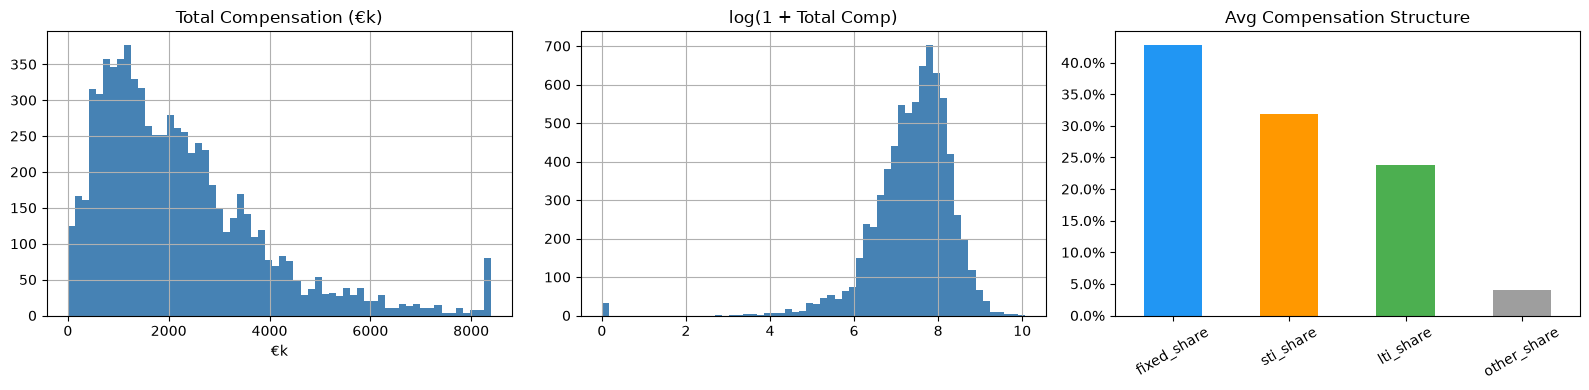

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Total comp distribution
df['total_comp'].dropna().clip(upper=df['total_comp'].quantile(0.99)).hist(
    bins=60, ax=axes[0], color='steelblue', edgecolor='none')
axes[0].set_title('Total Compensation (€k)')
axes[0].set_xlabel('€k')

# Log total comp
df['log_total_comp'].dropna().hist(
    bins=60, ax=axes[1], color='steelblue', edgecolor='none')
axes[1].set_title('log(1 + Total Comp)')

# Compensation structure
struct_mean = df[['fixed_share','sti_share','lti_share','other_share']].mean()
struct_mean.plot(kind='bar', ax=axes[2], color=['#2196F3','#FF9800','#4CAF50','#9E9E9E'])
axes[2].set_title('Avg Compensation Structure')
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 5 · Feature Matrix

In [6]:
FEATURE_COLS = [
    # Executive role
    'is_ceo', 'is_cfo',
    # Demographics
    'female', 'tenure_yrs', 'age_at_ye',
    # Board context
    'log_n_exec',
    # Index / company prestige
    'index_tier', 'in_dax', 'in_mdax',
    # Company financials (log-scaled)
    'log_TURN', 'log_TOAS', 'log_EMPL', 'log_STAF', 'log_EBTA',
    # Financial performance ratios
    'ROE', 'ROA', 'ROCE', 'PRMA', 'GRMA', 'CURR', 'SOLR', 'GEAR',
    # Derived
    'rd_intensity', 'debt_to_assets',
    # Time trend
    'year_centered',
]

TARGET_AMOUNT    = 'log_total_comp'
TARGET_STRUCTURE = ['fixed_share', 'sti_share', 'lti_share']

# ── Build modelling dataset ────────────────────────────────────────────────────
mask_amount = df[TARGET_AMOUNT].notna() & (df['total_comp'] > 0)
mod = df[mask_amount].copy()

print(f'Modelling rows: {len(mod):,}')
print(f'Feature columns: {len(FEATURE_COLS)}')

# Fill rate per feature
fill = mod[FEATURE_COLS].notna().mean().sort_values()
print('\nLowest fill rates:')
print(fill.head(10).round(3))

Modelling rows: 7,468
Feature columns: 25

Lowest fill rates:
rd_intensity   0.62
log_STAF       0.77
PRMA           0.77
GEAR           0.77
ROE            0.77
log_EBTA       0.78
ROA            0.78
ROCE           0.78
log_TOAS       0.78
SOLR           0.78
dtype: float64


In [7]:
# Time-based split: train on ≤2019, test on 2020–2024
# (avoids leakage across time; 2021 is a gap year)
train_mask = mod['year_num'] <= 2019
test_mask  = mod['year_num'] >= 2020

X_train = mod.loc[train_mask, FEATURE_COLS]
X_test  = mod.loc[test_mask,  FEATURE_COLS]
y_train = mod.loc[train_mask, TARGET_AMOUNT]
y_test  = mod.loc[test_mask,  TARGET_AMOUNT]

print(f'Train: {len(X_train):,} rows ({train_mask.sum()/len(mod):.0%}), years {mod.loc[train_mask,"year_num"].min()}–{mod.loc[train_mask,"year_num"].max()}')
print(f'Test:  {len(X_test):,} rows  ({test_mask.sum()/len(mod):.0%}), years {mod.loc[test_mask,"year_num"].min()}–{mod.loc[test_mask,"year_num"].max()}')

Train: 5,809 rows (78%), years 2006–2019
Test:  1,659 rows  (22%), years 2020–2024


## 6 · Model Training — Total Compensation Amount

We predict `log(1 + total_comp)` and report back-transformed metrics.

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

def make_preprocessing(feature_cols):
    """Impute medians, scale numerics."""
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
    ])

def eval_model(name, pipeline, X_tr, y_tr, X_te, y_te):
    pipeline.fit(X_tr, y_tr)
    pred = pipeline.predict(X_te)
    r2   = r2_score(y_te, pred)
    mae  = mean_absolute_error(y_te, pred)           # in log-€k units
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    # back-transform for intuitive MAE
    mae_k = mean_absolute_error(np.expm1(y_te), np.expm1(pred))
    return {'model': name, 'R²': r2, 'MAE_log': mae, 'RMSE_log': rmse, 'MAE_€k': mae_k, '_pipe': pipeline, '_pred': pred}

results = []

print('Preprocessing helper defined.')

Preprocessing helper defined.


In [9]:
# ── Ridge ──────────────────────────────────────────────────────────────────────
ridge_pipe = Pipeline([
    ('pre', make_preprocessing(FEATURE_COLS)),
    ('mdl', Ridge(alpha=1.0)),
])
r = eval_model('Ridge', ridge_pipe, X_train, y_train, X_test, y_test)
results.append(r)
print(f"Ridge  →  R²={r['R²']:.3f}  MAE_log={r['MAE_log']:.3f}  MAE_€k={r['MAE_€k']:.0f}k")

Ridge  →  R²=0.056  MAE_log=0.624  MAE_€k=1404k


In [10]:
# ── Lasso ─────────────────────────────────────────────────────────────────────
lasso_pipe = Pipeline([
    ('pre', make_preprocessing(FEATURE_COLS)),
    ('mdl', Lasso(alpha=0.01, max_iter=5000)),
])
r = eval_model('Lasso', lasso_pipe, X_train, y_train, X_test, y_test)
results.append(r)
print(f"Lasso  →  R²={r['R²']:.3f}  MAE_log={r['MAE_log']:.3f}  MAE_€k={r['MAE_€k']:.0f}k")

# Print non-zero Lasso coefficients
lasso_coef = pd.Series(
    lasso_pipe.named_steps['mdl'].coef_,
    index=FEATURE_COLS
).sort_values(key=abs, ascending=False)
print('\nNon-zero Lasso coefficients (top 15):')
print(lasso_coef[lasso_coef != 0].head(15).round(4))

Lasso  →  R²=0.074  MAE_log=0.619  MAE_€k=1401k

Non-zero Lasso coefficients (top 15):
is_ceo           0.23
in_dax           0.20
ROCE             0.11
tenure_yrs       0.10
year_centered    0.09
log_STAF         0.09
log_TOAS         0.08
rd_intensity     0.06
log_TURN         0.05
log_EMPL         0.05
is_cfo           0.04
index_tier       0.04
GRMA            -0.04
age_at_ye        0.03
PRMA             0.03
dtype: float64


In [11]:
# ── Random Forest ─────────────────────────────────────────────────────────────
rf_pipe = Pipeline([
    ('pre', SimpleImputer(strategy='median')),
    ('mdl', RandomForestRegressor(n_estimators=300, max_depth=12,
                                   min_samples_leaf=5, n_jobs=-1, random_state=42)),
])
r = eval_model('RandomForest', rf_pipe, X_train, y_train, X_test, y_test)
results.append(r)
print(f"RF     →  R²={r['R²']:.3f}  MAE_log={r['MAE_log']:.3f}  MAE_€k={r['MAE_€k']:.0f}k")

RF     →  R²=0.093  MAE_log=0.618  MAE_€k=1401k


In [12]:
# ── XGBoost ───────────────────────────────────────────────────────────────────
from sklearn.pipeline import Pipeline

xgb_pipe = Pipeline([
    ('pre', SimpleImputer(strategy='median')),
    ('mdl', xgb.XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        n_jobs=-1, random_state=42, verbosity=0
    )),
])
r = eval_model('XGBoost', xgb_pipe, X_train, y_train, X_test, y_test)
results.append(r)
print(f"XGB    →  R²={r['R²']:.3f}  MAE_log={r['MAE_log']:.3f}  MAE_€k={r['MAE_€k']:.0f}k")

XGB    →  R²=-0.039  MAE_log=0.658  MAE_€k=1441k


In [13]:
# ── LightGBM ──────────────────────────────────────────────────────────────────
lgb_pipe = Pipeline([
    ('pre', SimpleImputer(strategy='median')),
    ('mdl', lgb.LGBMRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=8,
        num_leaves=63, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        n_jobs=-1, random_state=42, verbose=-1
    )),
])
r = eval_model('LightGBM', lgb_pipe, X_train, y_train, X_test, y_test)
results.append(r)
print(f"LGB    →  R²={r['R²']:.3f}  MAE_log={r['MAE_log']:.3f}  MAE_€k={r['MAE_€k']:.0f}k")

LGB    →  R²=-0.117  MAE_log=0.686  MAE_€k=1481k


=== Total Compensation Amount — Model Comparison (held-out 2020–2024) ===
       model    R²  MAE_log  RMSE_log  MAE_€k
RandomForest  0.09     0.62      0.80 1401.29
       Lasso  0.07     0.62      0.80 1401.16
       Ridge  0.06     0.62      0.81 1404.19
     XGBoost -0.04     0.66      0.85 1440.50
    LightGBM -0.12     0.69      0.88 1481.16


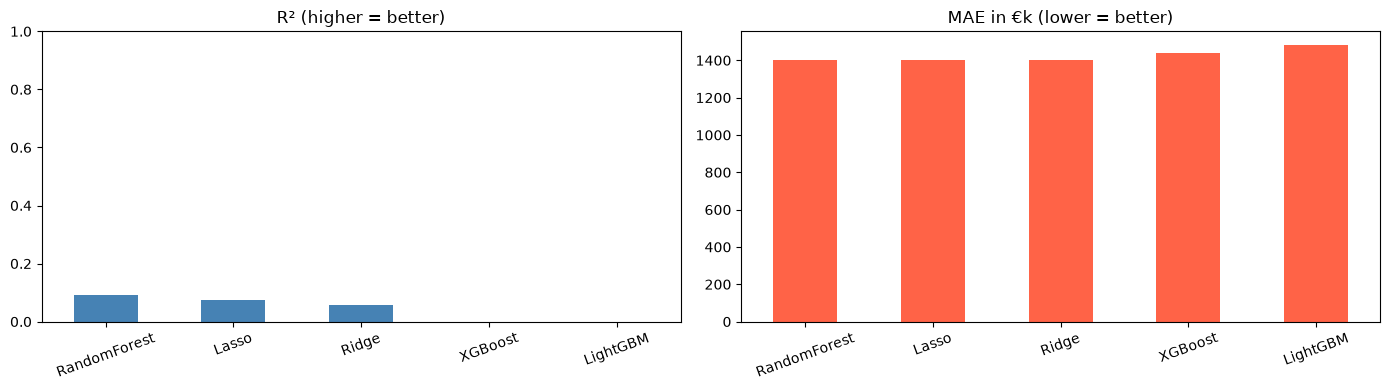

In [14]:
# ── Model comparison table ────────────────────────────────────────────────────
perf = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')} for r in results])
perf = perf.sort_values('R²', ascending=False).reset_index(drop=True)
print('=== Total Compensation Amount — Model Comparison (held-out 2020–2024) ===')
print(perf.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
perf.plot(x='model', y='R²', kind='bar', ax=axes[0], color='steelblue', legend=False)
axes[0].set_title('R² (higher = better)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)
axes[0].set_ylim(0, 1)

perf.plot(x='model', y='MAE_€k', kind='bar', ax=axes[1], color='tomato', legend=False)
axes[1].set_title('MAE in €k (lower = better)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

Best model: RandomForest  R²=0.093


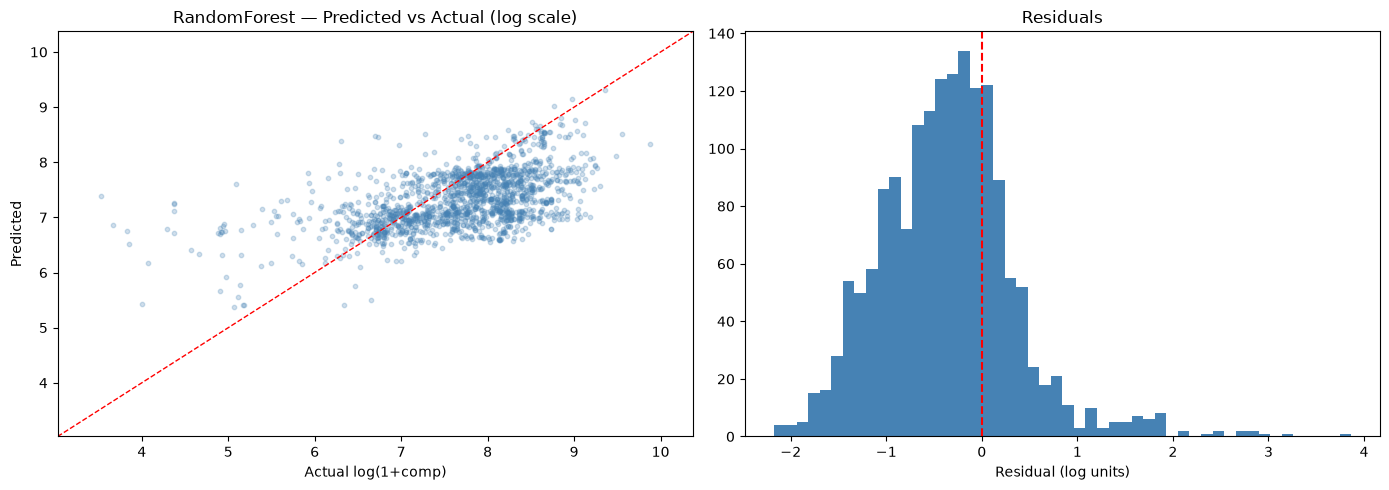

In [15]:
# Pick best model by R²
best_result = max(results, key=lambda r: r['R²'])
best_name   = best_result['model']
best_pipe   = best_result['_pipe']
best_pred   = best_result['_pred']
print(f'Best model: {best_name}  R²={best_result["R²"]:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs actual (log scale)
lim = (y_test.min() - 0.5, y_test.max() + 0.5)
axes[0].scatter(y_test, best_pred, alpha=0.25, s=10, color='steelblue')
axes[0].plot(lim, lim, 'r--', lw=1)
axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_xlabel('Actual log(1+comp)')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'{best_name} — Predicted vs Actual (log scale)')

# Residuals
resid = best_pred - y_test
axes[1].hist(resid, bins=50, color='steelblue', edgecolor='none')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual (log units)')
axes[1].set_title('Residuals')

plt.tight_layout()
plt.show()

## 7 · SHAP Feature Importance

SHAP values tell us not just *which* features matter but *how* they influence pay and in *which direction*.

In [16]:
# Use LightGBM (native SHAP, fast TreeExplainer)
lgb_pipe.fit(X_train, y_train)

lgb_model = lgb_pipe.named_steps['mdl']
imputer   = lgb_pipe.named_steps['pre']

X_test_imp  = pd.DataFrame(imputer.transform(X_test),  columns=FEATURE_COLS)
X_train_imp = pd.DataFrame(imputer.transform(X_train), columns=FEATURE_COLS)

explainer    = shap.TreeExplainer(lgb_model)
shap_values  = explainer.shap_values(X_test_imp)

print(f'SHAP matrix: {shap_values.shape}')

SHAP matrix: (1659, 25)


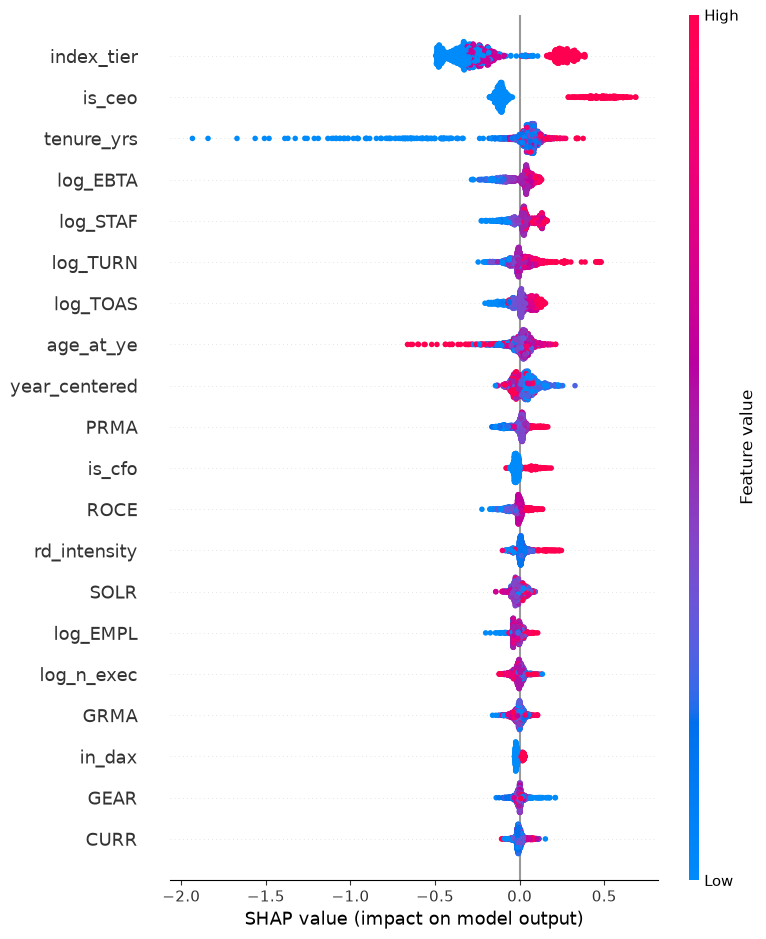

In [17]:
# Summary plot (beeswarm)
shap.summary_plot(shap_values, X_test_imp, feature_names=FEATURE_COLS,
                  plot_type='dot', max_display=20, show=True)

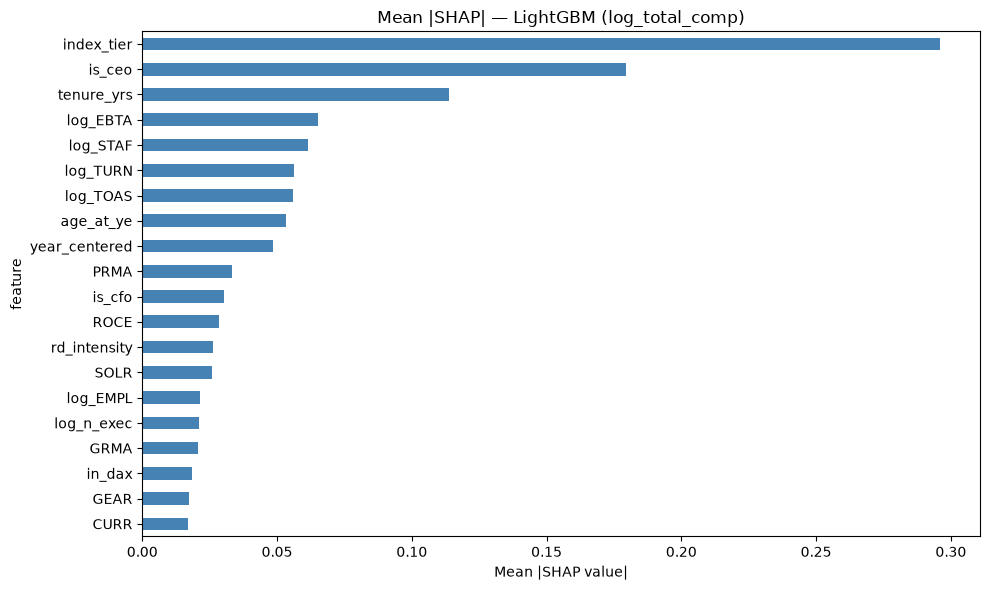

Top 10 most important features:
      feature  mean_abs_shap
   index_tier           0.30
       is_ceo           0.18
   tenure_yrs           0.11
     log_EBTA           0.07
     log_STAF           0.06
     log_TURN           0.06
     log_TOAS           0.06
    age_at_ye           0.05
year_centered           0.05
         PRMA           0.03


In [18]:
# Bar chart of mean |SHAP|
mean_shap = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({'feature': FEATURE_COLS, 'mean_abs_shap': mean_shap})\
            .sort_values('mean_abs_shap', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
shap_df.head(20).sort_values('mean_abs_shap').plot(
    x='feature', y='mean_abs_shap', kind='barh', ax=ax, color='steelblue', legend=False)
ax.set_title('Mean |SHAP| — LightGBM (log_total_comp)')
ax.set_xlabel('Mean |SHAP value|')
plt.tight_layout()
plt.show()

print('Top 10 most important features:')
print(shap_df.head(10).to_string(index=False))

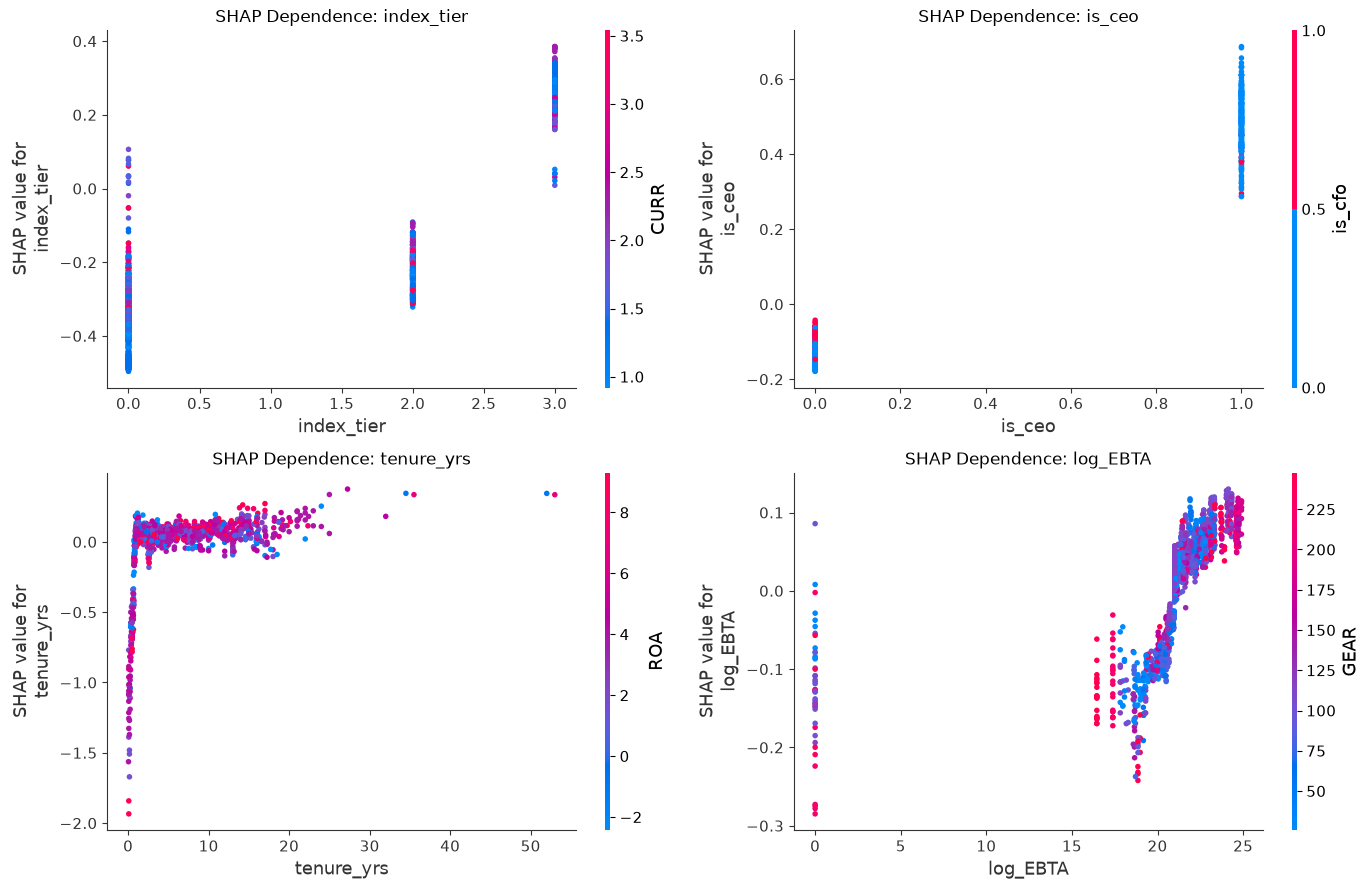

In [19]:
# Dependence plots for the top 4 features
top4 = shap_df.head(4)['feature'].tolist()
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, feat in enumerate(top4):
    shap.dependence_plot(
        feat, shap_values, X_test_imp,
        ax=axes[i], show=False
    )
    axes[i].set_title(f'SHAP Dependence: {feat}')

plt.tight_layout()
plt.show()

## 8 · CEO vs. Non-CEO — Separate Models

CEO compensation may respond to different drivers than other executives.  
We train separate XGBoost models for each group.

In [20]:
def run_split_model(label, mask_fn, df_mod, feature_cols, target):
    sub = df_mod[mask_fn(df_mod)].copy()
    tr  = sub['year_num'] <= 2019
    te  = sub['year_num'] >= 2020

    if tr.sum() < 50 or te.sum() < 10:
        print(f'{label}: too few rows (train={tr.sum()}, test={te.sum()}), skipping.')
        return None

    X_tr, X_te = sub.loc[tr, feature_cols], sub.loc[te, feature_cols]
    y_tr, y_te = sub.loc[tr, target],       sub.loc[te, target]

    pipe = Pipeline([
        ('pre', SimpleImputer(strategy='median')),
        ('mdl', lgb.LGBMRegressor(
            n_estimators=400, learning_rate=0.05, max_depth=7,
            num_leaves=31, subsample=0.8, colsample_bytree=0.8,
            n_jobs=-1, random_state=42, verbose=-1
        )),
    ])
    pipe.fit(X_tr, y_tr)
    pred = pipe.predict(X_te)

    r2    = r2_score(y_te, pred)
    mae_k = mean_absolute_error(np.expm1(y_te), np.expm1(pred))

    print(f'{label:20s}  train={tr.sum():>5,}  test={te.sum():>4,}  '
          f'R²={r2:.3f}  MAE={mae_k:.0f}k')

    # SHAP
    model_   = pipe.named_steps['mdl']
    imp_     = pipe.named_steps['pre']
    X_te_imp = pd.DataFrame(imp_.transform(X_te), columns=feature_cols)
    expl     = shap.TreeExplainer(model_)
    sv       = expl.shap_values(X_te_imp)

    mean_sv = np.abs(sv).mean(axis=0)
    imp_df  = pd.DataFrame({'feature': feature_cols, 'mean_abs_shap': mean_sv})\
                .sort_values('mean_abs_shap', ascending=False)
    return {'label': label, 'r2': r2, 'mae_k': mae_k,
            'shap_values': sv, 'X_test_imp': X_te_imp, 'imp_df': imp_df}

print('Running CEO / CFO / Other split models...')
ceo_res   = run_split_model('CEO',       lambda d: d['is_ceo'] == 1, mod, FEATURE_COLS, TARGET_AMOUNT)
nceo_res  = run_split_model('Non-CEO',   lambda d: d['is_ceo'] == 0, mod, FEATURE_COLS, TARGET_AMOUNT)
cfo_res   = run_split_model('CFO',       lambda d: (d['is_cfo'] == 1) & (d['is_ceo'] == 0), mod, FEATURE_COLS, TARGET_AMOUNT)

Running CEO / CFO / Other split models...
CEO                   train=1,095  test= 292  R²=-0.146  MAE=2167k
Non-CEO               train=4,714  test=1,367  R²=-0.136  MAE=1289k
CFO                   train=1,002  test= 269  R²=0.264  MAE=963k


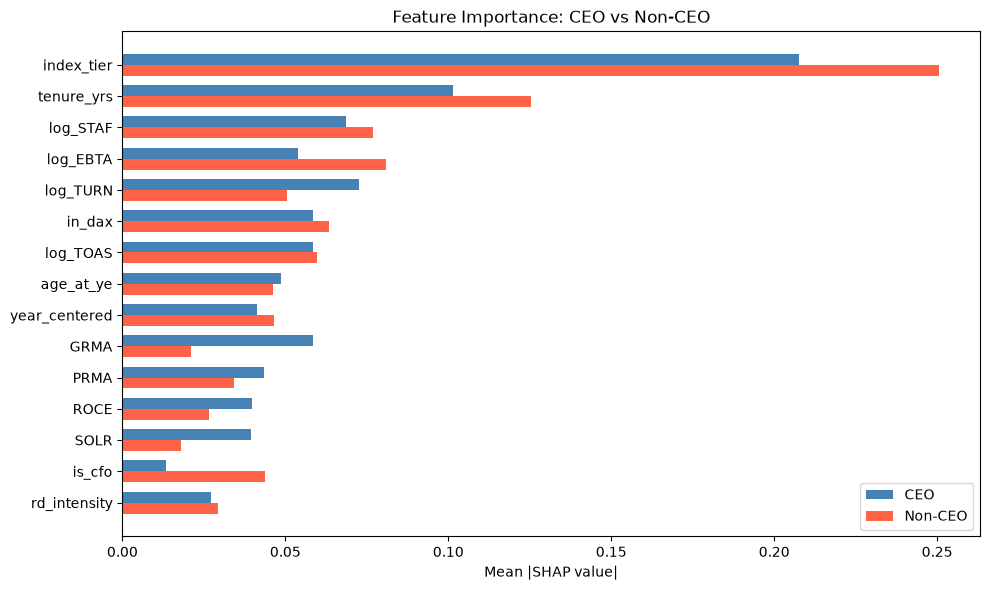

In [21]:
# Side-by-side SHAP importance: CEO vs Non-CEO
if ceo_res and nceo_res:
    top_n = 15
    ceo_imp  = ceo_res['imp_df'].set_index('feature')['mean_abs_shap'].rename('CEO')
    nceo_imp = nceo_res['imp_df'].set_index('feature')['mean_abs_shap'].rename('Non-CEO')
    cmp = pd.concat([ceo_imp, nceo_imp], axis=1).fillna(0)
    cmp['total'] = cmp['CEO'] + cmp['Non-CEO']
    cmp = cmp.sort_values('total', ascending=False).head(top_n)

    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(cmp))
    w = 0.35
    ax.barh(x - w/2, cmp['CEO'],     w, label='CEO',     color='steelblue')
    ax.barh(x + w/2, cmp['Non-CEO'], w, label='Non-CEO', color='tomato')
    ax.set_yticks(x)
    ax.set_yticklabels(cmp.index)
    ax.invert_yaxis()
    ax.legend()
    ax.set_xlabel('Mean |SHAP value|')
    ax.set_title('Feature Importance: CEO vs Non-CEO')
    plt.tight_layout()
    plt.show()

=== CEO SHAP Summary ===


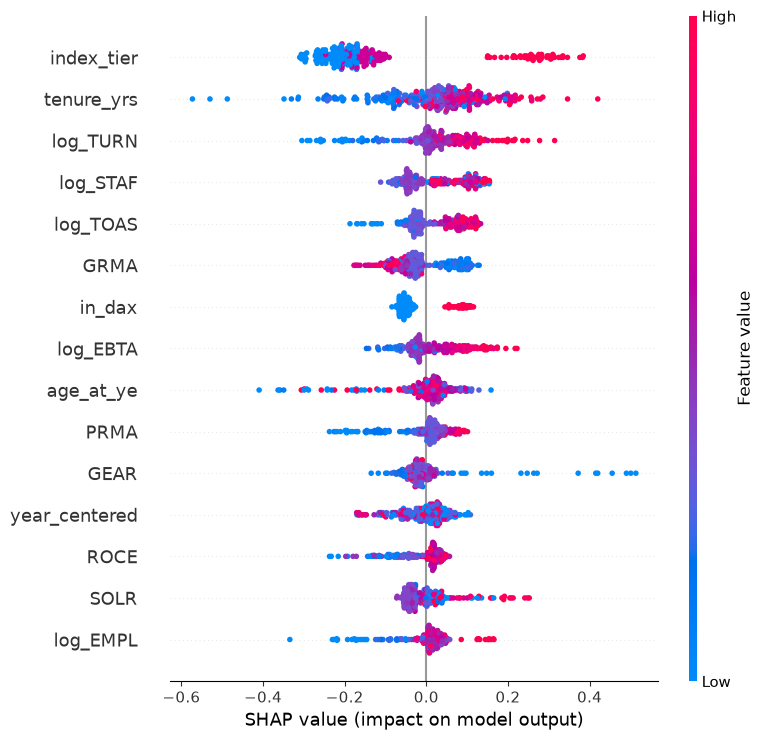

In [22]:
# Beeswarm for CEO
if ceo_res:
    print('=== CEO SHAP Summary ===')
    shap.summary_plot(ceo_res['shap_values'], ceo_res['X_test_imp'],
                      max_display=15, show=True)

=== Non-CEO SHAP Summary ===


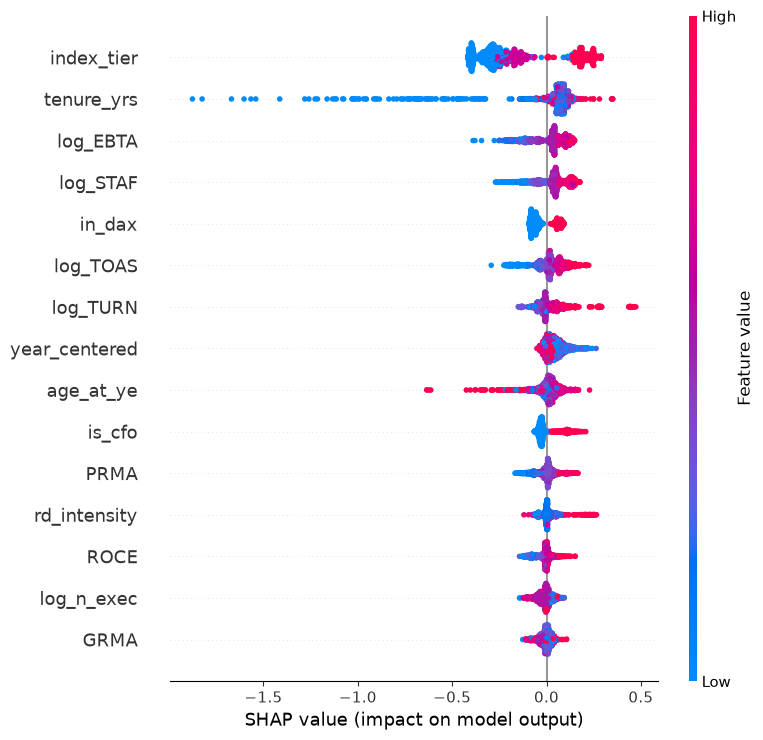

In [23]:
# Beeswarm for Non-CEO
if nceo_res:
    print('=== Non-CEO SHAP Summary ===')
    shap.summary_plot(nceo_res['shap_values'], nceo_res['X_test_imp'],
                      max_display=15, show=True)

## 9 · Compensation Structure Prediction

We predict the three shares simultaneously (`fixed_share`, `sti_share`, `lti_share`) using multi-output regression.  
We then analyse which features drive structure vs. level differently.

In [24]:
# Only rows where all three structure targets are available and valid
struct_mask = (
    mod[TARGET_STRUCTURE].notna().all(axis=1)
    & (mod['comp_sum'] > 0)
)
mod_s = mod[struct_mask].copy()
print(f'Structure modelling rows: {len(mod_s):,}')

tr_s = mod_s['year_num'] <= 2019
te_s = mod_s['year_num'] >= 2020

Xs_train = mod_s.loc[tr_s, FEATURE_COLS]
Xs_test  = mod_s.loc[te_s, FEATURE_COLS]
ys_train = mod_s.loc[tr_s, TARGET_STRUCTURE]
ys_test  = mod_s.loc[te_s, TARGET_STRUCTURE]

print(f'Train: {tr_s.sum():,}  Test: {te_s.sum():,}')

Structure modelling rows: 6,808
Train: 5,183  Test: 1,625


In [25]:
# Multi-output LightGBM (separate model per target)
struct_results = {}
struct_shaps   = {}

for target in TARGET_STRUCTURE:
    pipe = Pipeline([
        ('pre', SimpleImputer(strategy='median')),
        ('mdl', lgb.LGBMRegressor(
            n_estimators=400, learning_rate=0.05, max_depth=7,
            num_leaves=31, subsample=0.8, colsample_bytree=0.8,
            n_jobs=-1, random_state=42, verbose=-1
        )),
    ])
    pipe.fit(Xs_train, ys_train[target])
    pred = pipe.predict(Xs_test).clip(0, 1)

    r2  = r2_score(ys_test[target], pred)
    mae = mean_absolute_error(ys_test[target], pred)
    struct_results[target] = {'r2': r2, 'mae': mae, 'pipe': pipe, 'pred': pred}
    print(f'{target:15s}  R²={r2:.3f}  MAE={mae:.3f}')

    # SHAP
    model_   = pipe.named_steps['mdl']
    imp_     = pipe.named_steps['pre']
    X_te_imp = pd.DataFrame(imp_.transform(Xs_test), columns=FEATURE_COLS)
    expl     = shap.TreeExplainer(model_)
    sv       = expl.shap_values(X_te_imp)
    struct_shaps[target] = (sv, X_te_imp)

fixed_share      R²=-0.095  MAE=0.160
sti_share        R²=-0.006  MAE=0.129
lti_share        R²=0.012  MAE=0.154


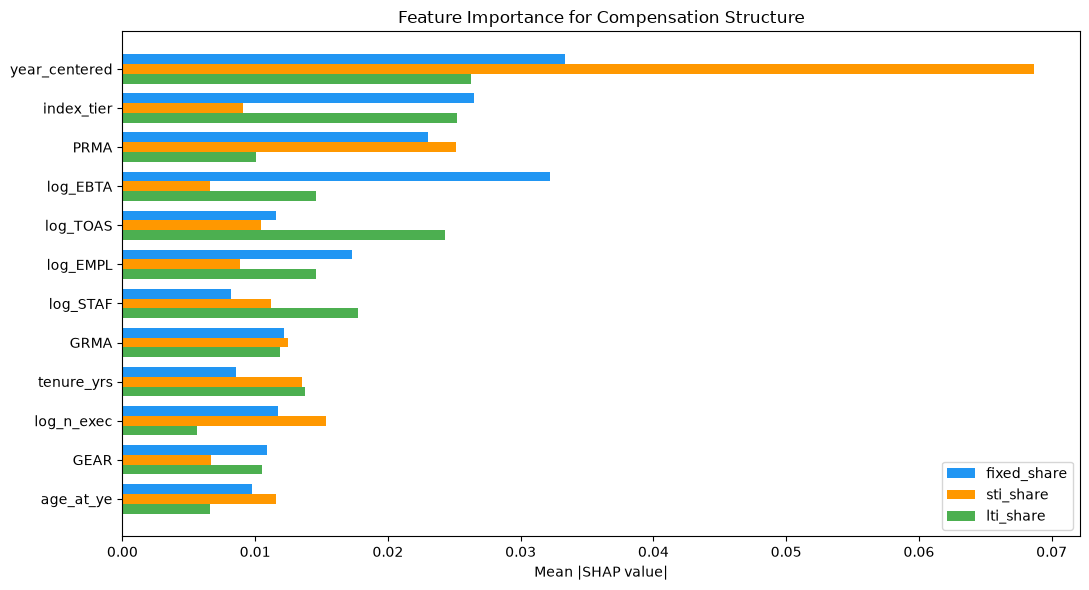

In [26]:
# Compare SHAP importance across structure targets
top_n = 12
shap_struct = {}
for t in TARGET_STRUCTURE:
    sv, _ = struct_shaps[t]
    shap_struct[t] = pd.Series(np.abs(sv).mean(axis=0), index=FEATURE_COLS)

cmp_struct = pd.DataFrame(shap_struct)
cmp_struct['total'] = cmp_struct.sum(axis=1)
cmp_struct = cmp_struct.sort_values('total', ascending=False).head(top_n)

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(cmp_struct))
w = 0.25
colors = ['#2196F3', '#FF9800', '#4CAF50']
for i, t in enumerate(TARGET_STRUCTURE):
    ax.barh(x - w + i*w, cmp_struct[t], w, label=t, color=colors[i])
ax.set_yticks(x)
ax.set_yticklabels(cmp_struct.index)
ax.invert_yaxis()
ax.legend()
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Feature Importance for Compensation Structure')
plt.tight_layout()
plt.show()

=== SHAP Summary: fixed_share ===


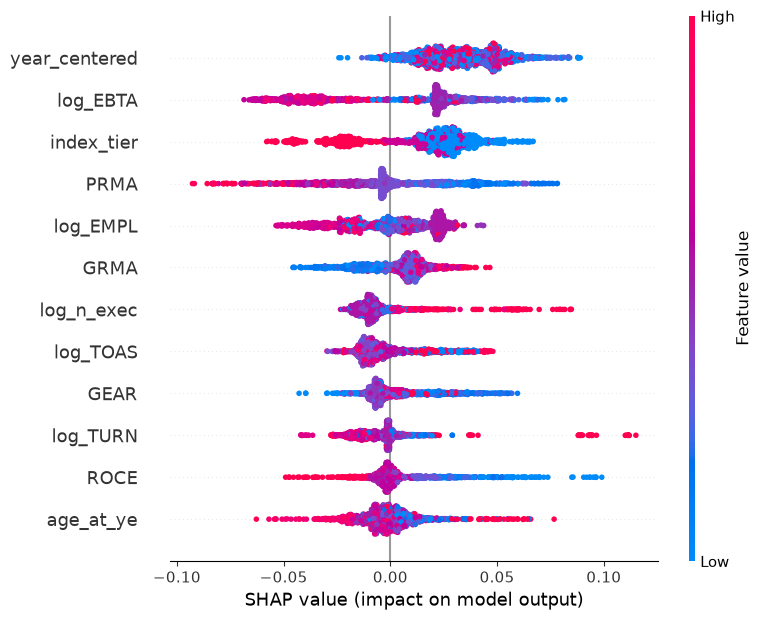

=== SHAP Summary: sti_share ===


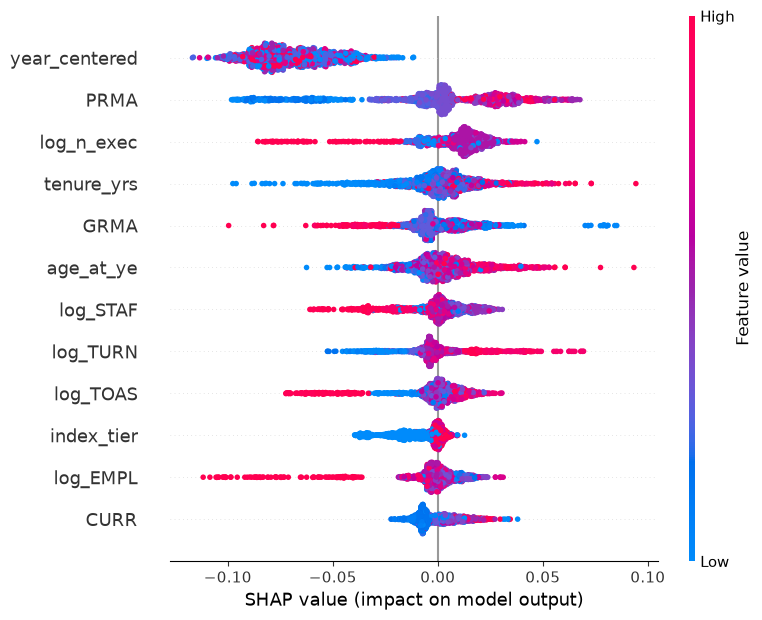

=== SHAP Summary: lti_share ===


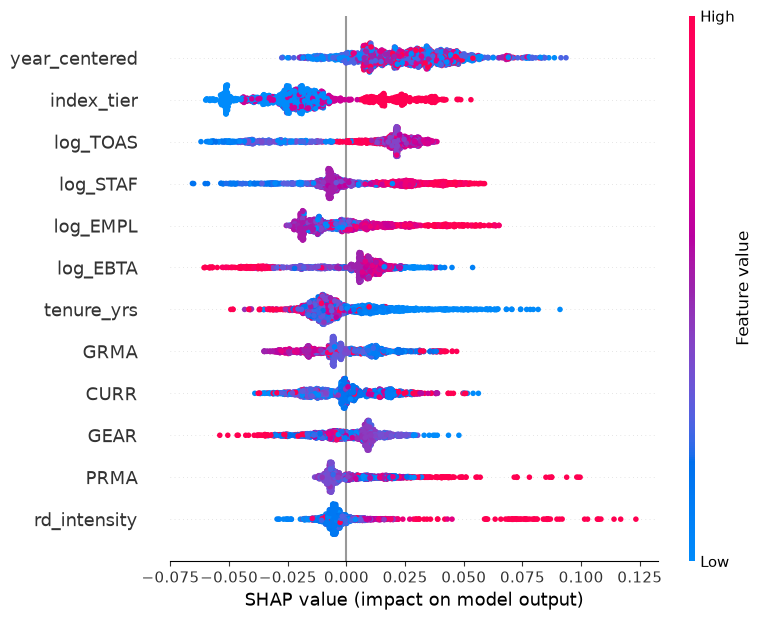

In [27]:
for t in TARGET_STRUCTURE:
    sv, X_te_imp = struct_shaps[t]
    print(f'=== SHAP Summary: {t} ===')
    shap.summary_plot(sv, X_te_imp, max_display=12, show=True)

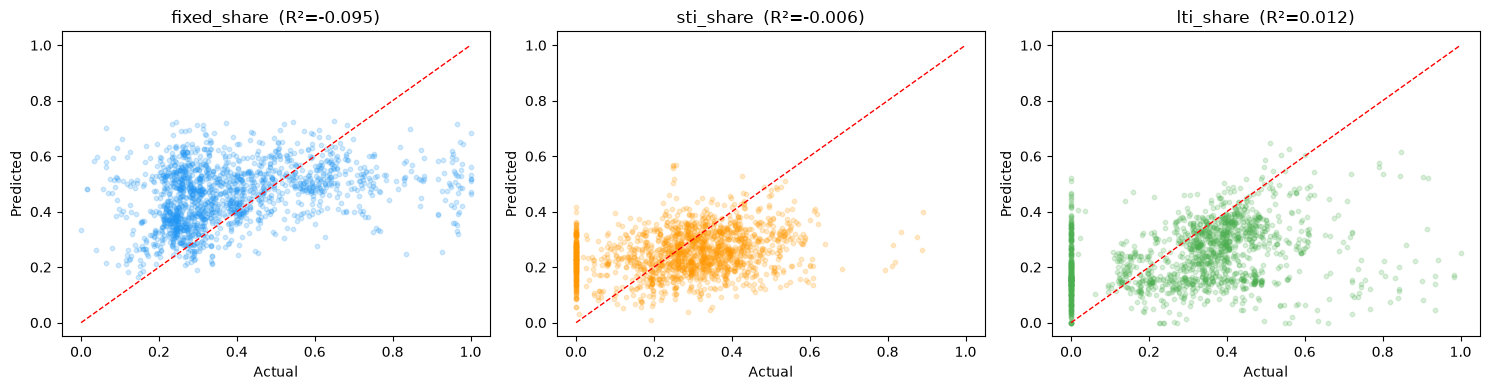

In [28]:
# Actual vs predicted structure — scatter per target
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, t in enumerate(TARGET_STRUCTURE):
    y_act  = ys_test[t].values
    y_pred = struct_results[t]['pred']
    axes[i].scatter(y_act, y_pred, alpha=0.2, s=10, color=colors[i])
    axes[i].plot([0,1],[0,1],'r--', lw=1)
    axes[i].set_xlim(-0.05, 1.05); axes[i].set_ylim(-0.05, 1.05)
    axes[i].set_xlabel('Actual')
    axes[i].set_ylabel('Predicted')
    r2 = struct_results[t]['r2']
    axes[i].set_title(f'{t}  (R²={r2:.3f})')
plt.tight_layout()
plt.show()

## 10 · Cross-Validation (Time-Series-aware)

Expanding-window CV: train up to year T, predict year T+1.

In [29]:
from sklearn.model_selection import cross_validate

cv_years   = sorted(mod['year_num'].unique())
# Use years 2012+ to have enough training data
test_years = [y for y in cv_years if y >= 2012 and y != 2021]

cv_results = []
for ty in test_years:
    tr = mod['year_num'] < ty
    te = mod['year_num'] == ty
    if tr.sum() < 100 or te.sum() < 20:
        continue

    Xtr = mod.loc[tr, FEATURE_COLS]
    Xte = mod.loc[te, FEATURE_COLS]
    ytr = mod.loc[tr, TARGET_AMOUNT]
    yte = mod.loc[te, TARGET_AMOUNT]

    imp  = SimpleImputer(strategy='median').fit(Xtr)
    mdl  = lgb.LGBMRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=7, verbose=-1,
        num_leaves=31, n_jobs=-1, random_state=42
    )
    mdl.fit(imp.transform(Xtr), ytr)
    pred = mdl.predict(imp.transform(Xte))

    r2   = r2_score(yte, pred)
    mae  = mean_absolute_error(np.expm1(yte), np.expm1(pred))
    cv_results.append({'test_year': ty, 'n_train': tr.sum(), 'n_test': te.sum(),
                       'R²': r2, 'MAE_€k': mae})

cv_df = pd.DataFrame(cv_results)
print(cv_df.to_string(index=False))
print(f'\nMean R²: {cv_df["R²"].mean():.3f}  ±{cv_df["R²"].std():.3f}')
print(f'Mean MAE: {cv_df["MAE_€k"].mean():.0f}k  ±{cv_df["MAE_€k"].std():.0f}k')

 test_year  n_train  n_test    R²  MAE_€k
      2012     2451     400  0.64  621.24
      2013     2851     403  0.55  740.40
      2014     3254     372  0.51  624.94
      2015     3626     391  0.50  751.55
      2016     4017     421  0.50  686.87
      2017     4438     469  0.45  767.72
      2018     4907     465  0.37  800.17
      2019     5372     437  0.42  724.54
      2020     5809     433  0.46  734.15
      2022     6697     255 -0.21 1658.98
      2023     6952     262  0.02 1309.02
      2024     7214     254  0.25 1445.72

Mean R²: 0.373  ±0.244
Mean MAE: 905k  ±353k


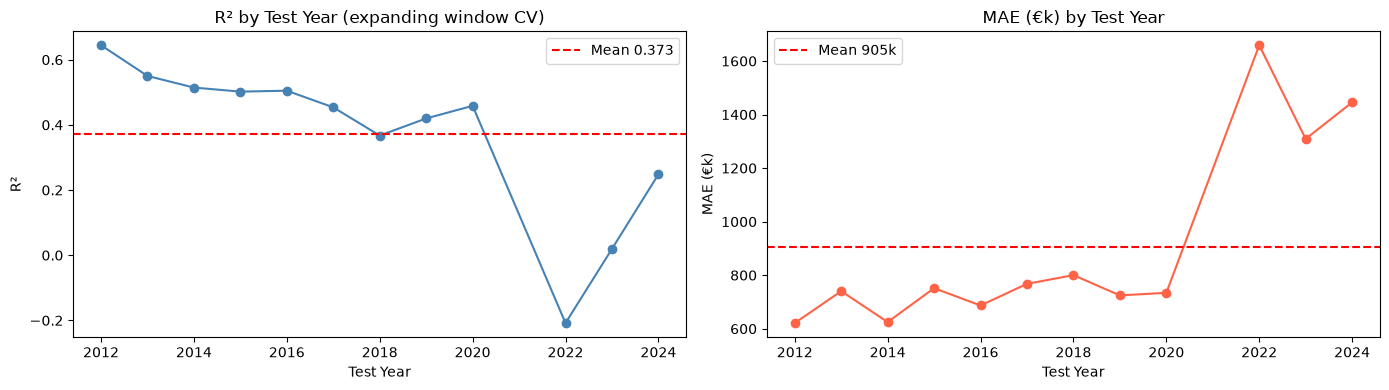

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(cv_df['test_year'], cv_df['R²'], marker='o', color='steelblue')
axes[0].axhline(cv_df['R²'].mean(), color='red', linestyle='--', label=f'Mean {cv_df["R²"].mean():.3f}')
axes[0].set_title('R² by Test Year (expanding window CV)')
axes[0].set_xlabel('Test Year')
axes[0].set_ylabel('R²')
axes[0].legend()

axes[1].plot(cv_df['test_year'], cv_df['MAE_€k'], marker='o', color='tomato')
axes[1].axhline(cv_df['MAE_€k'].mean(), color='red', linestyle='--', label=f'Mean {cv_df["MAE_€k"].mean():.0f}k')
axes[1].set_title('MAE (€k) by Test Year')
axes[1].set_xlabel('Test Year')
axes[1].set_ylabel('MAE (€k)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 11 · Ridge Coefficients — Linear Interpretation

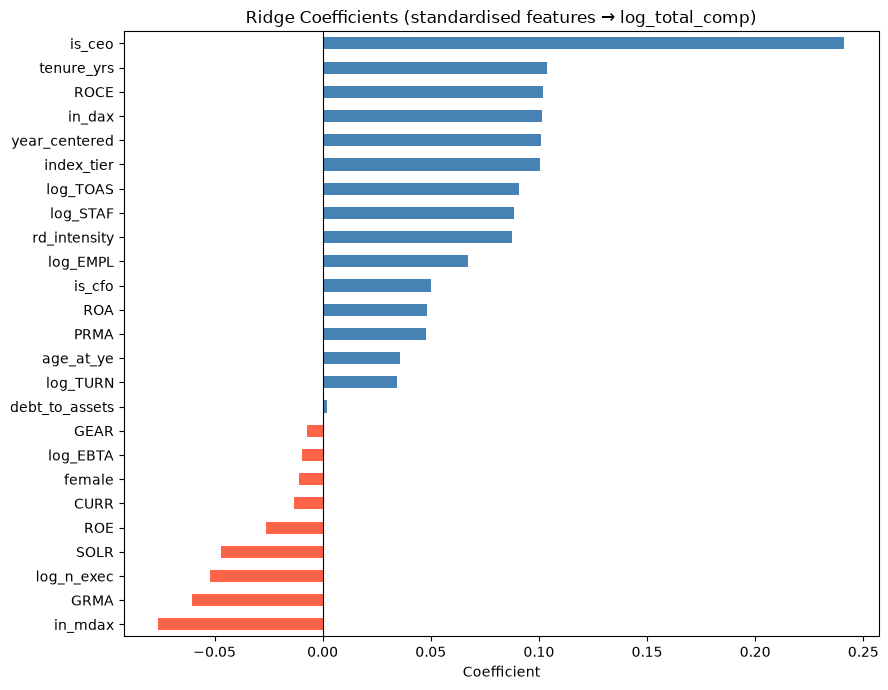

Ridge coefficients (standardised):
in_mdax          -0.08
GRMA             -0.06
log_n_exec       -0.05
SOLR             -0.05
ROE              -0.03
CURR             -0.01
female           -0.01
log_EBTA         -0.01
GEAR             -0.01
debt_to_assets    0.00
log_TURN          0.03
age_at_ye         0.04
PRMA              0.05
ROA               0.05
is_cfo            0.05
log_EMPL          0.07
rd_intensity      0.09
log_STAF          0.09
log_TOAS          0.09
index_tier        0.10
year_centered     0.10
in_dax            0.10
ROCE              0.10
tenure_yrs        0.10
is_ceo            0.24


In [31]:
# Standardised Ridge coefficients give a clean linear story
ridge_pipe.fit(X_train, y_train)
coef = pd.Series(
    ridge_pipe.named_steps['mdl'].coef_,
    index=FEATURE_COLS
).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
colors_c = ['tomato' if v < 0 else 'steelblue' for v in coef]
coef.plot(kind='barh', ax=ax, color=colors_c)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Ridge Coefficients (standardised features → log_total_comp)')
ax.set_xlabel('Coefficient')
plt.tight_layout()
plt.show()

print('Ridge coefficients (standardised):')
print(coef.round(4).to_string())

## 12 · Summary & Key Findings

## 13 · Distribution Shift: 2008–2020 vs 2022–2024

The poor held-out R² on 2020–2024 warrants investigation.  
The 2022–2024 data comes from a different source (DSW) covering only large-cap companies,  
while 2008–2020 covers a broader index universe. This creates a **covariate shift**.

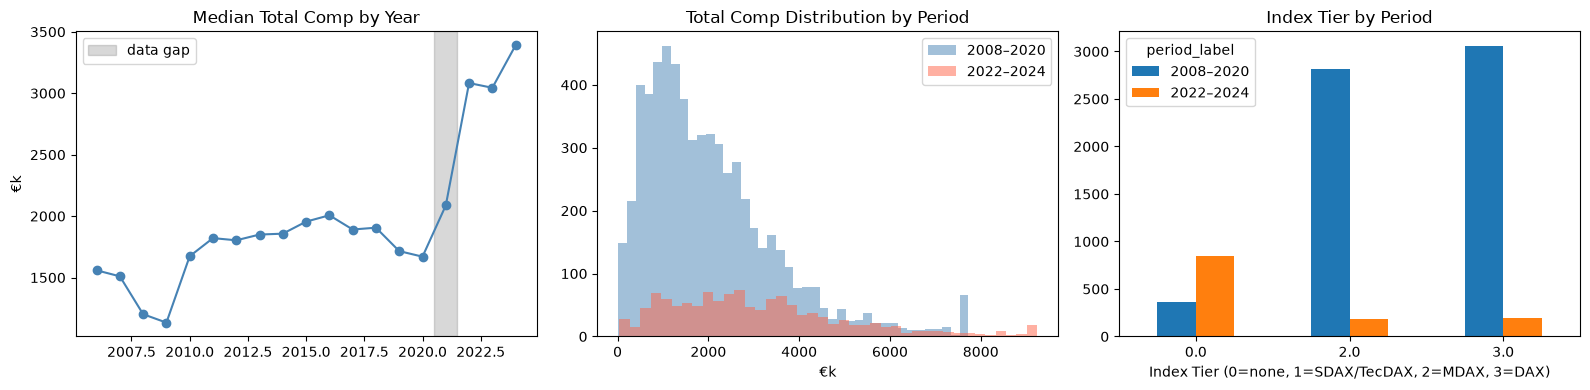


Total comp summary by period:
               count    mean     std   min     25%     50%     75%      max
period_label                                                               
2008–2020    6242.00 2076.00 1644.00 16.00  962.00 1717.00 2735.00 23450.00
2022–2024    1226.00 3096.00 2057.00 38.00 1571.00 2734.00 4048.00 19426.00

Index listing by period:
index_listing   DAX  DAX and MDAX  MDAX
period_label                           
2008–2020      3059           158  2815
2022–2024       192            74   189


In [32]:

# ── Compare total_comp distributions by period ────────────────────────────────
period_map = {y: ('2008–2020' if y <= 2020 else '2022–2024') for y in mod['year_num'].unique()}
mod['period_label'] = mod['year_num'].map(period_map)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Median total_comp over time
yr_med = mod.groupby('year_num')['total_comp'].median()
axes[0].plot(yr_med.index, yr_med.values, marker='o', color='steelblue')
axes[0].axvspan(2020.5, 2021.5, color='grey', alpha=0.3, label='data gap')
axes[0].set_title('Median Total Comp by Year')
axes[0].set_ylabel('€k')
axes[0].legend()

# Distribution by period
for p, col in [('2008–2020', 'steelblue'), ('2022–2024', 'tomato')]:
    vals = mod.loc[mod['period_label'] == p, 'total_comp'].dropna()
    axes[1].hist(vals.clip(upper=vals.quantile(0.99)), bins=40, alpha=0.5, label=p, color=col)
axes[1].set_title('Total Comp Distribution by Period')
axes[1].set_xlabel('€k')
axes[1].legend()

# Index tier by period
it_period = mod.groupby(['period_label', 'index_tier']).size().unstack(fill_value=0)
it_period.T.plot(kind='bar', ax=axes[2])
axes[2].set_title('Index Tier by Period')
axes[2].set_xlabel('Index Tier (0=none, 1=SDAX/TecDAX, 2=MDAX, 3=DAX)')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print('\nTotal comp summary by period:')
print(mod.groupby('period_label')['total_comp'].describe().round(0))
print('\nIndex listing by period:')
print(mod.groupby(['period_label', 'index_listing']).size().unstack(fill_value=0))

## 14 · Within-Period Models + Company Target Encoding

Company identity is a strong predictor — firms have stable pay cultures.  
We encode each company's **historical median log-pay** as a feature (leave-one-out / expanding-window safe).  
We also run a clean **2008–2020-only** expanding-window CV to separate modelling quality from data-source shift.

In [33]:

# ── Company target encoding (expanding window — no leakage) ───────────────────
# For each row at year T, we encode the company's mean log-comp across all years < T.
mod_te = mod.sort_values('year_num').copy()

# global fallback mean
global_mean = mod_te[TARGET_AMOUNT].mean()

company_hist_mean = []
for idx, row in mod_te.iterrows():
    past = mod_te.loc[(mod_te['company_shortname'] == row['company_shortname'])
                      & (mod_te['year_num'] < row['year_num']), TARGET_AMOUNT]
    company_hist_mean.append(past.mean() if len(past) > 0 else global_mean)

mod_te['company_log_comp_hist'] = company_hist_mean

# ── CEO-level target encoding (expanding window) ───────────────────────────────
ceo_hist_mean = []
for idx, row in mod_te.iterrows():
    past = mod_te.loc[(mod_te['is_ceo'] == row['is_ceo'])
                      & (mod_te['year_num'] < row['year_num']), TARGET_AMOUNT]
    ceo_hist_mean.append(past.mean() if len(past) > 0 else global_mean)

mod_te['role_log_comp_hist'] = ceo_hist_mean

FEATURE_COLS_TE = FEATURE_COLS + ['company_log_comp_hist', 'role_log_comp_hist']
print(f'Extended feature set: {len(FEATURE_COLS_TE)} features')
print('Fill rate for new features:')
print(mod_te[['company_log_comp_hist', 'role_log_comp_hist']].notna().mean().round(3))

Extended feature set: 27 features
Fill rate for new features:
company_log_comp_hist   1.00
role_log_comp_hist      1.00
dtype: float64


In [34]:

# ── Model with target encoding — all years, time-based split ──────────────────
tr_te = mod_te['year_num'] <= 2019
te_te = mod_te['year_num'] >= 2020

results_te = []
for model_name, estimator in [
    ('Ridge+TE',    Ridge(alpha=1.0)),
    ('LightGBM+TE', lgb.LGBMRegressor(n_estimators=400, learning_rate=0.05, max_depth=7,
                                       num_leaves=31, subsample=0.8, colsample_bytree=0.8,
                                       n_jobs=-1, random_state=42, verbose=-1)),
]:
    pipe = Pipeline([
        ('pre', SimpleImputer(strategy='median')),
        ('scl', StandardScaler() if 'Ridge' in model_name else 'passthrough'),
        ('mdl', estimator),
    ])
    Xtr = mod_te.loc[tr_te, FEATURE_COLS_TE]
    Xte = mod_te.loc[te_te, FEATURE_COLS_TE]
    ytr = mod_te.loc[tr_te, TARGET_AMOUNT]
    yte = mod_te.loc[te_te, TARGET_AMOUNT]

    pipe.fit(Xtr, ytr)
    pred  = pipe.predict(Xte)
    r2    = r2_score(yte, pred)
    mae_k = mean_absolute_error(np.expm1(yte), np.expm1(pred))
    results_te.append({'model': model_name, 'R²': r2, 'MAE_€k': mae_k})
    print(f'{model_name:20s}  R²={r2:.3f}  MAE={mae_k:.0f}k')

print('\nImprovement vs. baseline (no target encoding):')
for rt in results_te:
    base = next((r for r in results if r['model'].replace('+TE','') in rt['model']), None)
    if base:
        print(f"  {rt['model']:20s}  ΔR²={rt['R²']-base['R²']:+.3f}")

Ridge+TE              R²=0.145  MAE=1334k
LightGBM+TE           R²=0.230  MAE=1293k

Improvement vs. baseline (no target encoding):
  Ridge+TE              ΔR²=+0.088
  LightGBM+TE           ΔR²=+0.347


=== Within-2008-2020 expanding-window CV (LightGBM + target encoding) ===
 test_year  n_train  n_test   R²  MAE_€k
      2012     2451     400 0.71  546.97
      2013     2851     403 0.63  609.90
      2014     3254     372 0.53  581.57
      2015     3626     391 0.52  720.77
      2016     4017     421 0.56  654.03
      2017     4438     469 0.53  661.96
      2018     4907     465 0.44  736.07
      2019     5372     437 0.44  675.57
      2020     5809     433 0.53  678.50

Mean R²: 0.545  ±0.086
Mean MAE: 652k  ±62k


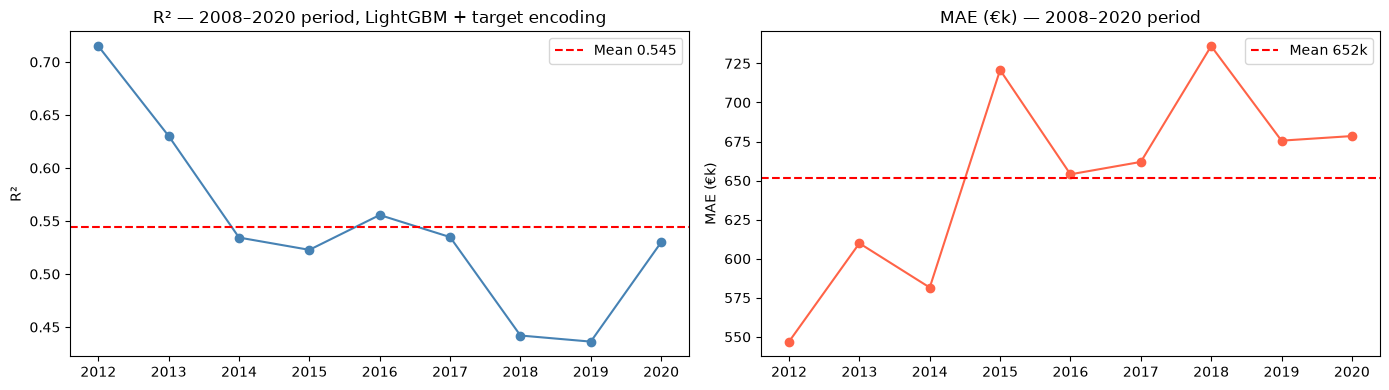

In [35]:

# ── Within-2008-2020 only: rolling-window CV (cleanest signal) ────────────────
mod_pre = mod_te[mod_te['year_num'] <= 2020].copy()

cv_pre_results = []
for ty in range(2012, 2021):
    tr = mod_pre['year_num'] < ty
    te = mod_pre['year_num'] == ty
    if tr.sum() < 50 or te.sum() < 10:
        continue

    Xtr = mod_pre.loc[tr, FEATURE_COLS_TE]
    Xte = mod_pre.loc[te, FEATURE_COLS_TE]
    ytr = mod_pre.loc[tr, TARGET_AMOUNT]
    yte = mod_pre.loc[te, TARGET_AMOUNT]

    imp = SimpleImputer(strategy='median').fit(Xtr)
    mdl = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=7,
                              num_leaves=31, n_jobs=-1, random_state=42, verbose=-1)
    mdl.fit(imp.transform(Xtr), ytr)
    pred = mdl.predict(imp.transform(Xte))

    r2   = r2_score(yte, pred)
    mae  = mean_absolute_error(np.expm1(yte), np.expm1(pred))
    cv_pre_results.append({'test_year': ty, 'n_train': tr.sum(), 'n_test': te.sum(),
                            'R²': r2, 'MAE_€k': mae})

cv_pre_df = pd.DataFrame(cv_pre_results)
print('=== Within-2008-2020 expanding-window CV (LightGBM + target encoding) ===')
print(cv_pre_df.to_string(index=False))
print(f'\nMean R²: {cv_pre_df["R²"].mean():.3f}  ±{cv_pre_df["R²"].std():.3f}')
print(f'Mean MAE: {cv_pre_df["MAE_€k"].mean():.0f}k  ±{cv_pre_df["MAE_€k"].std():.0f}k')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(cv_pre_df['test_year'], cv_pre_df['R²'], marker='o', color='steelblue')
axes[0].axhline(cv_pre_df['R²'].mean(), color='red', linestyle='--',
                label=f'Mean {cv_pre_df["R²"].mean():.3f}')
axes[0].set_title('R² — 2008–2020 period, LightGBM + target encoding')
axes[0].set_ylabel('R²'); axes[0].legend()

axes[1].plot(cv_pre_df['test_year'], cv_pre_df['MAE_€k'], marker='o', color='tomato')
axes[1].axhline(cv_pre_df['MAE_€k'].mean(), color='red', linestyle='--',
                label=f'Mean {cv_pre_df["MAE_€k"].mean():.0f}k')
axes[1].set_title('MAE (€k) — 2008–2020 period')
axes[1].set_ylabel('MAE (€k)'); axes[1].legend()

plt.tight_layout()
plt.show()

R² on 2020 (academic period): 0.531

SHAP importance with target encoding:
              feature  mean_abs_shap
company_log_comp_hist           0.23
               is_ceo           0.13
           index_tier           0.12
           tenure_yrs           0.12
             log_EBTA           0.07
   role_log_comp_hist           0.05
                 PRMA           0.04
             log_STAF           0.04
            age_at_ye           0.04
             log_TOAS           0.03
           log_n_exec           0.03
               is_cfo           0.03
         rd_intensity           0.03
             log_TURN           0.03
                 ROCE           0.03


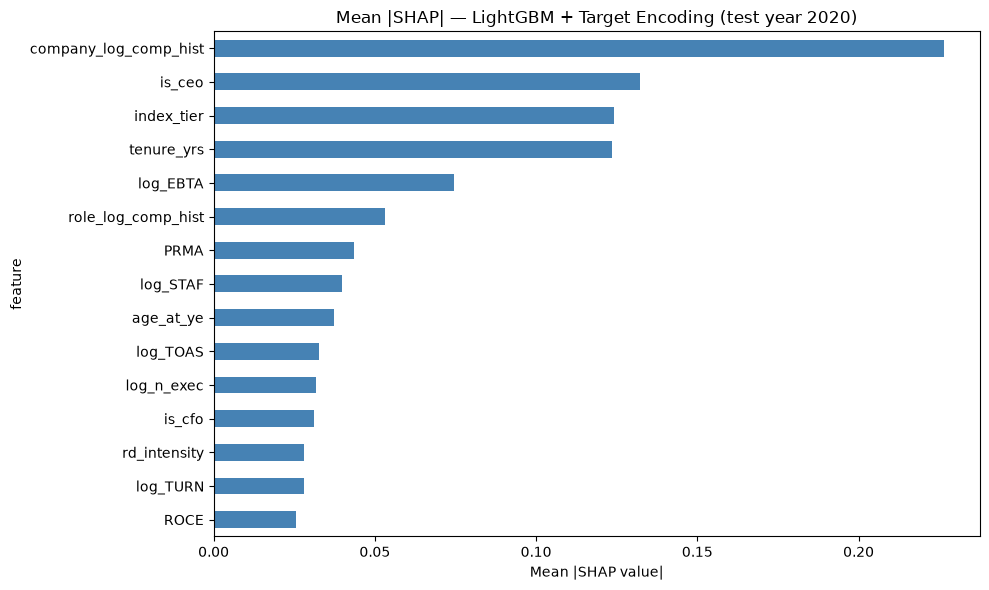

In [36]:

# ── SHAP for best model with target encoding ─────────────────────────────────
# Train on 2008-2019, explain on 2020 within academic period (cleanest comparison)
tr_cl = mod_te['year_num'] <= 2019
te_cl = mod_te['year_num'] == 2020

Xtr_cl = mod_te.loc[tr_cl, FEATURE_COLS_TE]
Xte_cl = mod_te.loc[te_cl, FEATURE_COLS_TE]
ytr_cl = mod_te.loc[tr_cl, TARGET_AMOUNT]
yte_cl = mod_te.loc[te_cl, TARGET_AMOUNT]

imp_cl = SimpleImputer(strategy='median').fit(Xtr_cl)
mdl_cl = lgb.LGBMRegressor(n_estimators=400, learning_rate=0.05, max_depth=7,
                             num_leaves=31, n_jobs=-1, random_state=42, verbose=-1)
mdl_cl.fit(imp_cl.transform(Xtr_cl), ytr_cl)

Xte_cl_imp = pd.DataFrame(imp_cl.transform(Xte_cl), columns=FEATURE_COLS_TE)
expl_cl  = shap.TreeExplainer(mdl_cl)
sv_cl    = expl_cl.shap_values(Xte_cl_imp)

mean_sv_cl = np.abs(sv_cl).mean(axis=0)
shap_te_df = pd.DataFrame({'feature': FEATURE_COLS_TE, 'mean_abs_shap': mean_sv_cl})\
               .sort_values('mean_abs_shap', ascending=False)

print(f'R² on 2020 (academic period): {r2_score(yte_cl, mdl_cl.predict(imp_cl.transform(Xte_cl))):.3f}')
print()
print('SHAP importance with target encoding:')
print(shap_te_df.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
shap_te_df.head(15).sort_values('mean_abs_shap').plot(
    x='feature', y='mean_abs_shap', kind='barh', ax=ax, color='steelblue', legend=False)
ax.set_title('Mean |SHAP| — LightGBM + Target Encoding (test year 2020)')
ax.set_xlabel('Mean |SHAP value|')
plt.tight_layout()
plt.show()

=== SHAP beeswarm: LightGBM + Target Encoding ===


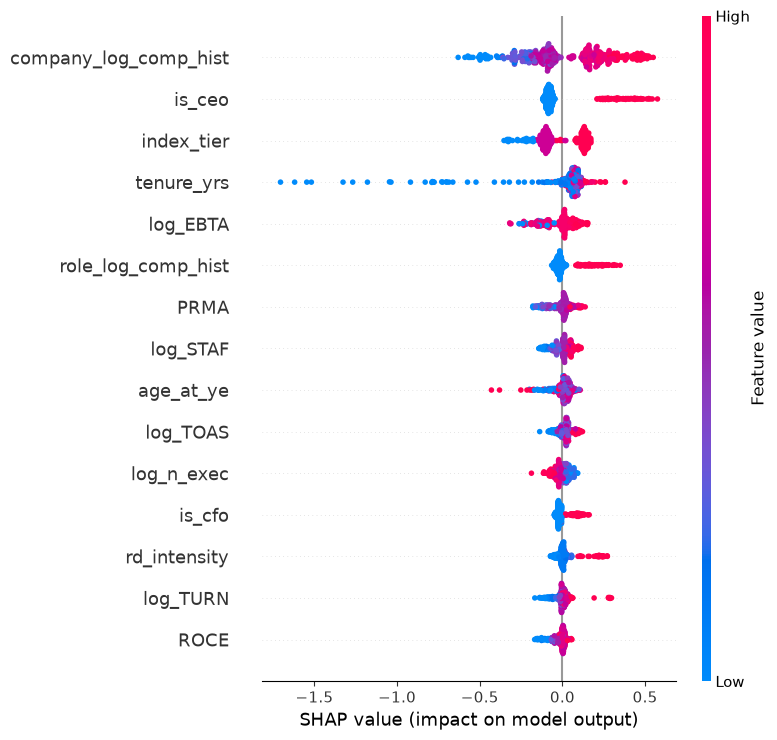

In [37]:

# ── Beeswarm with target encoding features ───────────────────────────────────
print('=== SHAP beeswarm: LightGBM + Target Encoding ===')
shap.summary_plot(sv_cl, Xte_cl_imp, feature_names=FEATURE_COLS_TE, max_display=15, show=True)

In [38]:
print('=' * 65)
print('EXECUTIVE COMPENSATION MODELLING — SUMMARY')
print('=' * 65)

print('\n─── A. Compensation Level (log_total_comp) ─────────────────────')
for r in results:
    print(f"  {r['model']:15s}  R²={r['R²']:.3f}  MAE={r['MAE_€k']:.0f}k")

print('\n─── B. Compensation Structure ───────────────────────────────────')
for t in TARGET_STRUCTURE:
    sr = struct_results[t]
    print(f"  {t:15s}  R²={sr['r2']:.3f}  MAE={sr['mae']:.3f}")

print('\n─── C. Top Features (SHAP, all execs) ──────────────────────────')
top10 = shap_df.head(10)
for _, row in top10.iterrows():
    print(f"  {row['feature']:25s}  mean|SHAP|={row['mean_abs_shap']:.4f}")

print()
print('─── D. Cross-Validation (expanding window, LightGBM) ────────────')
print(f"  Mean R²:  {cv_df['R²'].mean():.3f}  ±{cv_df['R²'].std():.3f}")
print(f"  Mean MAE: {cv_df['MAE_€k'].mean():.0f}k  ±{cv_df['MAE_€k'].std():.0f}k")
print()

EXECUTIVE COMPENSATION MODELLING — SUMMARY

─── A. Compensation Level (log_total_comp) ─────────────────────
  Ridge            R²=0.056  MAE=1404k
  Lasso            R²=0.074  MAE=1401k
  RandomForest     R²=0.093  MAE=1401k
  XGBoost          R²=-0.039  MAE=1441k
  LightGBM         R²=-0.117  MAE=1481k

─── B. Compensation Structure ───────────────────────────────────
  fixed_share      R²=-0.095  MAE=0.160
  sti_share        R²=-0.006  MAE=0.129
  lti_share        R²=0.012  MAE=0.154

─── C. Top Features (SHAP, all execs) ──────────────────────────
  index_tier                 mean|SHAP|=0.2960
  is_ceo                     mean|SHAP|=0.1793
  tenure_yrs                 mean|SHAP|=0.1139
  log_EBTA                   mean|SHAP|=0.0651
  log_STAF                   mean|SHAP|=0.0614
  log_TURN                   mean|SHAP|=0.0562
  log_TOAS                   mean|SHAP|=0.0558
  age_at_ye                  mean|SHAP|=0.0535
  year_centered              mean|SHAP|=0.0485
  PRMA             